In [1]:
# --------------------------------------------------------
# 
# Postprocess results from the longrun set of simulations
# 
# --------------------------------------------------------

In [1]:
# --- CDR calc note 
# --- from Yoshi (Jan 17, 2024)
# (-CO2_dif_exp-CO2_rsp_exp)-(-CO2_dif_spn-CO2_rsp_spn) - 0.14*(CO2_adv_exp - CO2_adv_spn).
# In the above equation CO2_dif denotes face values in the "diff" column for int_flux_gas-pco2.txt file,  
# CO2_adv in the column of "adv", CO2_rsp in the "g2" column (OM phase considered).  
# "exp" denotes ERW experiments while spn controls/spin-ups.

In [2]:
# --- Decide which CDR calculations to perform
cdr_calc_list = ["co2_flx",       
                 "camg_flx",
                 "totcat_flx",
                 # "carbalk_flx", # (turn this back on when the runs are re-run with fixed cflx file)
                 "rockdiss"]
# ---

In [3]:
import fnmatch
import glob
import os
import pickle
import sys
import re
from typing import Tuple

import cmocean.cm as cmo
import fsspec         # for AWS integration
import s3fs
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D  # for custom legend entries (needed for contour plot)
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# --- read in cdr calculation functions  
from ew_workflows import cdr_fxns_postproc as cfp
# ---

# ************************************************
# --- [ settings ]
EXP_SET = 'longrunOAT'
multiyear = False
batchname = f"{EXP_SET}_monthly_ltm_annual_v0.csv"
runtype = "field"
time_horizon = 100.   # set the time_horizon for computing the integrated flux 
dustsp = "gbas" # TODO: update `emissions_calculator_df` to use the `dustsp` in the df if mineral is None
ctrl_conditions = {"dustrate": 0} 
collapse_cols = [ # [ list or None ] # params that are analyzed one at a time, rather than all combinations (we don't want an xr dimension for each param)
    "dustrad", "secondary_min_rule", "poro_updated",
] 
dfin_cols_to_keep = [   # become dimensions in later xr dataset
    "dustrate_ton_ha_yr", "site",
] 
dfin_cols_to_keep_time = dfin_cols_to_keep + ["time"]
# ************************************************


# --- read in the batch .csv
batchdir = "s3://carbonplan-carbon-removal/ew-workflows-data/scepter/batch/"
dfin = pd.read_csv(os.path.join(batchdir, batchname))

# ---
# groundwork
outdir = f"s3://carbonplan-carbon-removal/SCEPTER/scepter_output/{EXP_SET}"

In [4]:
# --- add column for the full run ID
if multiyear:
    dfin["newrun_id_full"] = dfin["newrun_id"] + f"_composite_{runtype}"
else:
    dfin['newrun_id_full'] = dfin['newrun_id'] + "_" + dfin['dustsp'] + "_" + runtype + "_tau"+dfin["duration"].astype(float).astype(str).str.replace(".", "p")  # (duration has to be turned into float first because otherwise we miss the decimal pt)

# identify the control run(s)
dfin = cfp.find_control_runs(dfin, ctrl_conditions)
# add a column for the dustrate in ton_ha_yr
if "dustrate" in dfin.columns:
    dfin["dustrate_ton_ha_yr"] = dfin["dustrate"] / 100 

# add dustrad if we only have psdrain_meanRad
if "dustrad" not in dfin.columns:
    dfin['dustrad'] = dfin['psdrain_meanRad'] * 1e6 # [ convert m to um ]

# --- extract sites
sitenames = dfin['site'].unique()

# --- create the collapsed col
if collapse_cols:
    dfin["collapsed_inputs"] = dfin[collapse_cols].apply(
       lambda row: " | ".join(f"{col}={row[col]}" for col in collapse_cols),
        axis=1
    )
    # update the ds coords
    dfin_cols_to_keep = dfin_cols_to_keep + ["collapsed_inputs"]
    dfin_cols_to_keep_time = dfin_cols_to_keep_time + ["collapsed_inputs"]


In [5]:
# f"{dfin['aws_bucket'].iloc[63]} -- {dfin['newrun_id_full'].iloc[63]}"#.columns

# Flux postprocessing

In [6]:
# --- read in the postprocessed flux data 
# [ integrated flux ]
flx_dict_int = cfp.read_postproc_flux(
    dfin, outdir, cdr_calc_list, dfin_cols_to_keep, 
    flx_type="int_flx", rockdiss_feedstock=None
)
# [ flux ]
flx_dict = cfp.read_postproc_flux(
    dfin, outdir, cdr_calc_list, dfin_cols_to_keep, 
    flx_type="flx", rockdiss_feedstock=None
)

solving co2_flx
could not find longrunOAT_monthly_ltm_annual_v0_4_central_valley_monthly_ltm_app_0p0_0_gbas_field_tau100p0 -- run 0
could not find longrunOAT_monthly_ltm_annual_v0_4_central_valley_monthly_ltm_app_10p0_4_gbas_field_tau100p0 -- run 4
could not find longrunOAT_monthly_ltm_annual_v0_4_central_valley_monthly_ltm_app_200p0_6_gbas_field_tau100p0 -- run 6
could not find longrunOAT_monthly_ltm_annual_v0_4_central_valley_monthly_ltm_app_500p0_7_gbas_field_tau100p0 -- run 7
could not find longrunOAT_monthly_ltm_annual_v0_4_central_valley_monthly_ltm_app_10p0_28_gbas_field_tau100p0 -- run 28
could not find longrunOAT_monthly_ltm_annual_v0_4_central_valley_monthly_ltm_app_10p0_76_gbas_field_tau100p0 -- run 76
could not find longrunOAT_monthly_ltm_annual_v0_4_central_valley_monthly_ltm_app_1500p0_80_gbas_field_tau100p0 -- run 80
could not find longrunOAT_monthly_ltm_annual_v0_4_central_valley_monthly_ltm_app_4000p0_105_gbas_field_tau100p0 -- run 105
solving camg_flx
solving totcat_f

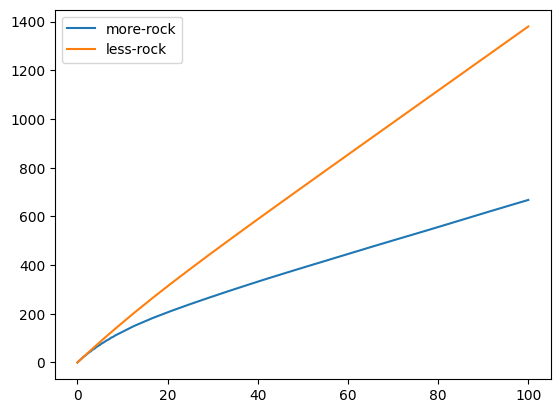

In [7]:
tmpdf = flx_dict_int['co2_flx'].copy()
tmpdf1 = tmpdf[tmpdf['runname']=="longrunOAT_monthly_ltm_annual_v0_264_cornbelt_monthly_ltm_app_4000p0_63_gbas_field_tau100p0"]
tmpdf2 = tmpdf[tmpdf['runname']=="longrunOAT_monthly_ltm_annual_v0_264_cornbelt_monthly_ltm_app_10p0_10_gbas_field_tau100p0"]


plt.plot(tmpdf1['time'],tmpdf1['co2flx_dif'],label='more-rock')
plt.plot(tmpdf2['time'],tmpdf2['co2flx_dif'],label='less-rock')
plt.legend()
# conds = {
#     "site": "264_cornbelt",
#     "dustrate_ton_ha_yr": 0.1, 
#     "collapsed_inputs": 'dustrad=10.0 | secondary_min_rule=sld_track | poro_updated=0.35'
# }
# tmpdf = dfx_cdr_short[dfx_cdr_short[list(conds)].eq(conds).all(axis=1)].copy()

In [ ]:
dfin[dfin['newrun_id_full'] == tmpdf1['runname'].iloc[0]]['dustrad']
dfin[dfin['newrun_id_full'] == tmpdf1['runname'].iloc[0]]['secondary_min_rule']
dfin[dfin['newrun_id_full'] == tmpdf1['runname'].iloc[0]]['poro_updated']

dfin[dfin['newrun_id_full'] == tmpdf2['runname'].iloc[0]]['dustrad']
dfin[dfin['newrun_id_full'] == tmpdf2['runname'].iloc[0]]['secondary_min_rule']
dfin[dfin['newrun_id_full'] == tmpdf2['runname'].iloc[0]]['poro_updated']

runnames = dfin[
    (dfin['site'] == "264_cornbelt")
    & (dfin['dustrad'] == 75.)
    & (dfin['secondary_min_rule']=="remove")
    & (dfin['poro_updated'] == 0.35)
]['newrun_id_full']
dusts = dfin[
    (dfin['site'] == "264_cornbelt")
    & (dfin['dustrad'] == 75.)
    & (dfin['secondary_min_rule']=="remove")
    & (dfin['poro_updated'] == 0.35)
]['dustrate']

idx=0
tdf_ctrl = tmpdf[tmpdf['runname'] == 'longrunOAT_monthly_ltm_annual_v0_264_cornbelt_monthly_ltm_app_0p0_1_gbas_field_tau100p0'].reset_index(drop=True)
for rn in runnames.values:
    tdf = tmpdf[tmpdf['runname']==rn].reset_index(drop=True)
    plt.plot(tdf['time'],tdf['co2flx_dif']-tdf_ctrl['co2flx_dif'],label=dusts.values[idx])
    idx+=1
plt.legend()


In [ ]:
dfin[
    (dfin['site'] == "264_cornbelt")
    & (dfin['dustrad'] == 75.)
    & (dfin['secondary_min_rule']=="sld_track")
    & (dfin['poro_updated'] == 0.25)]

In [7]:
# --- compute CDR fluxes (with losses considered)
# ---
# [ time-integrated ]
cdr_dict_int_full, cdr_dict_int_sum = cfp.cdr_int_per_group(
    flx_dict_int, time_horizon, 
    cdr_calc_list, dfin_cols_to_keep,
    bysite = True
)
# [ transient ]
cdr_dict_full, cdr_dict_sum = cfp.cdr_int_per_group(
    flx_dict, time_horizon, 
    cdr_calc_list, dfin_cols_to_keep,
    bysite = True
)

solving co2_flx
solving camg_flx
solving totcat_flx
solving rockdiss
solving co2_flx
solving camg_flx
solving totcat_flx
solving rockdiss


In [ ]:
tmpdfx=cdr_dict_int_full['co2_flx'].copy()
conds = {
    "site": "390_southeast",
    "dustrate_ton_ha_yr": 15, 
    "collapsed_inputs": 'dustrad=75.0 | secondary_min_rule=sld_track | poro_updated=0.25'
}
conds2 = {
    "site": "390_southeast",
    "dustrate_ton_ha_yr": 40, 
    "collapsed_inputs": 'dustrad=75.0 | secondary_min_rule=sld_track | poro_updated=0.25'
}
tmpdfx1 = tmpdfx[tmpdfx[list(conds)].eq(conds).all(axis=1)].copy()
tmpdfx2 = tmpdfx[tmpdfx[list(conds2)].eq(conds2).all(axis=1)].copy()

plt.plot(tmpdfx1['time'],tmpdfx1['cdr_dif'],label='more-rock')
plt.plot(tmpdfx2['time'],tmpdfx2['cdr_dif'],label='less-rock')
plt.legend()


In [ ]:
# # --- get emissions 
# dustrate_name = "dustrate_ton_ha_yr" # note, we multiply by duration in emissions_calc, so we only want annual rate here
# # set the inputs ***************
# p80_input = 1.3e3
# truck_km = 0.1e3
# barge_km = 0.0e3
# barge_diesel_km = 0
# Efactor_org = "MRO"
# # ******************************

# cdr_dict_sum['rockdiss'] = cfp.emissions_calculator_df(
#     cdr_dict_int_sum['rockdiss'], dustrate_name, 
#     p80_input, truck_km, barge_km, barge_diesel_km, 
#     Efactor_org, mineral=dustsp
# )


In [11]:
# --- compute CDR w/ loss rates and convert to xr datasets
outds_int = cfp.cdr_ds(
    cdr_dict = cdr_dict_int_sum, dims = dfin_cols_to_keep, 
    cdr_calc_list = cdr_calc_list, convert_time_to_timestep = False,
)
# --- repeat for time-dependent time-integrated data
outds_int_time = cfp.cdr_ds(
    cdr_dict = cdr_dict_int_full, dims = dfin_cols_to_keep_time, 
    cdr_calc_list = cdr_calc_list, skip_loss = True,
    convert_time_to_timestep = True,
)
# --- repeat for time-transient data (note dims now includes "time")
outds = cfp.cdr_ds(
    cdr_dict = cdr_dict_full, dims = dfin_cols_to_keep_time, 
    cdr_calc_list = cdr_calc_list, skip_loss = True, 
    convert_time_to_timestep = True,
)


solving co2_flx
solving camg_flx
solving totcat_flx
solving rockdiss
solving co2_flx
solving camg_flx
solving totcat_flx


/Users/tylerkukla/Documents/GitHub/ew-workflows/src/ew_workflows/cdr_fxns_postproc.py:1606: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'dustrate_ton_ha_yr' ('dustrate_ton_ha_yr',) The recommendation is to set join explicitly for this case.
  dsout = xr.merge(dsout_dict.values())
/Users/tylerkukla/Documents/GitHub/ew-workflows/src/ew_workflows/cdr_fxns_postproc.py:1606: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dsout 

solving rockdiss
solving co2_flx
solving camg_flx
solving totcat_flx
solving rockdiss


/Users/tylerkukla/Documents/GitHub/ew-workflows/src/ew_workflows/cdr_fxns_postproc.py:1606: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'dustrate_ton_ha_yr' ('dustrate_ton_ha_yr',) The recommendation is to set join explicitly for this case.
  dsout = xr.merge(dsout_dict.values())
/Users/tylerkukla/Documents/GitHub/ew-workflows/src/ew_workflows/cdr_fxns_postproc.py:1606: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dsout 

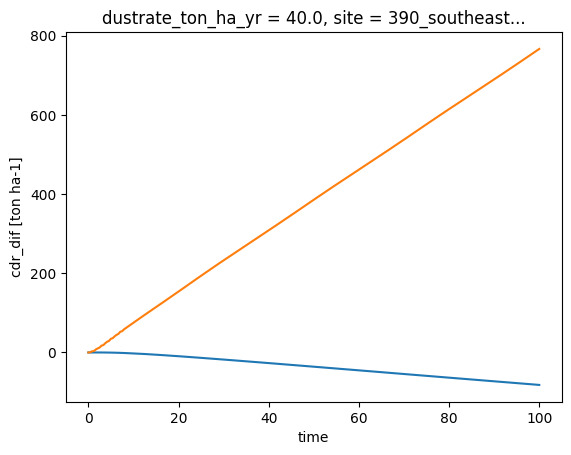

In [16]:
outds_int_time.isel(dustrate_ton_ha_yr = 0, site=1, collapsed_inputs=0)['cdr_dif'].plot()
outds_int_time.isel(dustrate_ton_ha_yr = 5, site=1, collapsed_inputs=0)['cdr_dif'].plot()

In [ ]:
outds_int_time#['co2_flx']
# # dsx_full = outds.copy()
# # dsx_full = dsx_full.swap_dims({"time_step": "time"})

# dsx_full = xr.merge(outds_int_time.values())


# other_dims = [d for d in dsx_full.dims if d != "time_step"]

# timetol=1e-2

# # compute std and mean across experiments at each time_step
# time_std = dsx_full['time'].std(dim=other_dims)
# time_mean = dsx_full['time'].mean(dim=other_dims)
# max_abs_diff = time_std.max().item()
# max_rel_diff = (time_std / time_mean).max().item()
# # --- [ TROUBLESHOOT ] ---
# # print("Max absolute difference:", max_abs_diff)
# # print("Max relative difference:", max_rel_diff)
# if max_abs_diff < timetol: # add time to cdr dataset
#     dsx_full = dsx_full.assign_coords(time=time_mean)
#     dsx_full = dsx_full.swap_dims({"time_step": "time"})
# #    return dsx_full
# #else:
# #    raise ValueError("Simulation time


# dsx_full

# # tc = 'co2_flx'
# # print(f"solving {tc}")
# # dfin = cdr_dict_int_full[tc]
# # cfp.co2_flx_cdr_ds(
# #     dfin, dfin_cols_to_keep_time, loss_percents=np.linspace(100,1,50), skip_loss=True, 
# #     convert_time_to_timestep=True,
# # )

/var/folders/2r/w7zcr7vx4p5cr7n4d0b51f4c0000gn/T/ipykernel_50054/413884626.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'dustrate_ton_ha_yr' ('dustrate_ton_ha_yr',) The recommendation is to set join explicitly for this case.
  dsx_full = xr.merge(outds_int_time.values())
/var/folders/2r/w7zcr7vx4p5cr7n4d0b51f4c0000gn/T/ipykernel_50054/413884626.py:5: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dsx_full = xr.merge(o

<xarray.Dataset> Size: 3MB
Dimensions:                       (dustrate_ton_ha_yr: 10, site: 4, time: 64,
                                   collapsed_inputs: 5)
Coordinates:
  * dustrate_ton_ha_yr            (dustrate_ton_ha_yr) float64 80B 0.1 ... 1....
  * site                          (site) object 32B '264_cornbelt' ... '4_cen...
    time_step                     (time) int64 512B 0 1 2 3 4 ... 59 60 61 62 63
  * collapsed_inputs              (collapsed_inputs) object 40B 'dustrad=10.0...
  * time                          (time) float64 512B 0.0008343 ... 100.0
Data variables: (12/32)
    cdr_dif                       (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    cdr_adv                       (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    cdr_adv_plus_newSIC           (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    cdr_SIConly                   (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    tot_adv                       (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    cdr_dif_component             (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    ...                            ...
    dust_minus_adv                (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    total_dissolution             (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    fraction_sld_advected         (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    fraction_sld_remaining        (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    fraction_remaining_dissolved  (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
    fraction_total_dissolved      (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 102kB ...
Attributes:
    flx_type:  int_flx

In [ ]:
def df_to_ds_with_time(
        dims_full: list,
        dfx: list,
        timetol: float=1e-2
)->xr.Dataset:
    """
    convert pandas dataframe to xarray dataset in cases where we have multiple 
    models with the same number of timesteps but slightly different time values
    --> we make timestep index a dimension, then take the mean time per timestep
        then add that as a dimension and return the result
    """
    timetol = 1e-2
    groupby_list = [x for x in dims_full if x != "time"]
    # replace `time` with `time_step`
    dims_full = ['time_step' if c == 'time' else c for c in dims_full]
    # add time_step to the dataframe
    dfx['time_step'] = (
        dfx.groupby(groupby_list)
        .cumcount()
    )
    # create the cdr dataset
    dfx_full_idx = dfx.set_index(dims_full)
    dsx_full = xr.Dataset.from_dataframe(dfx_full_idx)
    # look at variability in time across experiments
    other_dims = [d for d in dsx_full.dims if d != "time_step"]

    # compute std and mean across experiments at each time_step
    time_std = dsx_full['time'].std(dim=other_dims)
    time_mean = dsx_full['time'].mean(dim=other_dims)
    max_abs_diff = time_std.max().item()
    max_rel_diff = (time_std / time_mean).max().item()
    # --- [ TROUBLESHOOT ] ---
    # print("Max absolute difference:", max_abs_diff)
    # print("Max relative difference:", max_rel_diff)
    if max_abs_diff < timetol: # add time to cdr dataset
        dsx_full = dsx_full.assign_coords(time=time_mean)
        dsx_full = dsx_full.swap_dims({"time_step": "time"})
        return dsx_full
    else:
        raise ValueError("Simulation timesteps are not similar enough to make an xarray dataset")

# Profile postprocessing

In [ ]:
# --- prepare the post-processing inputs
# 
batch_axes = dfin_cols_to_keep
#
# dictionary for which files to process in the batch profile functions
proc_dict = {
    "adsorbed": False,
    "adsorbed_percCEC": True,
    "adsorbed_ppm": False,
    "aqueous": True,
    "aqueous_total": False,
    "bulksoil": True,
    "exchange_total": False,
    "gas": True,
    "rate": False,
    "soil_ph": True,
    "solid": False,
    "solid_sp_saturation": True, 
    "solid_volumePercent": True,
    "solid_weightPercent": True,
    "specific_surface_area": True,
    "surface_area": False,
}


In [ ]:
# --- compile all the profile .nc data into a single dataset
dsdict = cfp.prof_batchprocess_allvars(
    outdir, dustsp, dfin, batch_axes, proc_dict, 
    print_loop_updates = False
)

In [ ]:
dsdict['adsorbed_percCEC'].isel(
    dustrate_ton_ha_yr=5, site=0, collapsed_inputs=1
)['ca']#.plot()

In [ ]:
dsdict['solid_weightPercent'].isel(
    dustrate_ton_ha_yr=5, site=2, collapsed_inputs=1
).collapsed_inputs

In [ ]:
import xarray as xr
xr.backends.list_engines()

# --------- SCRATCH -------------

In [ ]:
# outds
outds_int

# outds_int_time.isel(
#     dustrate_ton_ha_yr = 4,
#     site=2,
#     collapsed_inputs=2
# )['cdr_dif'].plot()

# outds_int.isel(
#     dustrate_ton_ha_yr = 0,
#     site=0,
#     collapsed_inputs=0
# )['cdr_dif'].plot()

In [ ]:
outds_int_time.isel(
        dustrate_ton_ha_yr = 0,
        site=2,
        collapsed_inputs=4,
    ).collapsed_inputs

In [ ]:
outds_int_time

In [ ]:
pvar = "cdr_dif_component"
for inp in range(5):
    # if inp == 3: 
    #     continue
    outds_int_time.isel(
        dustrate_ton_ha_yr = 5,
        site=0,
        collapsed_inputs=inp,
    )[pvar].plot(label=inp)
    plt.legend()
    # plt.xscale('log')
    # plt.xlim(0.1,100)

In [ ]:
tmpdf1 = cdr_dict_int_full['co2_flx'].copy()
tmpdf2 = tmpdf1[tmpdf1['site'] == "264_cornbelt"]
dustratesx = tmpdf2['dustrate_ton_ha_yr'].unique()
for thisdustrate in dustratesx:
    tmpdf3 = tmpdf2[tmpdf2['dustrate_ton_ha_yr'] == thisdustrate]
    plt.plot(tmpdf3['time'], tmpdf3['cdr_dif'], linewidth=1)

In [ ]:
outds_int_time.isel(
        dustrate_ton_ha_yr = 5,
        site=0,
        collapsed_inputs=0,
    )[pvar]

## TEST one site.. then build for all

In [ ]:
# --- TEST ---  POSTPROCESS ONE SITE 
df = dfin[dfin['site'] == sitenames[1]].copy().reset_index(drop=True)
# --- read in the postprocessed flux data 
# [ integrated flux ]
flx_dict_int = cfp.read_postproc_flux(
    df, outdir, cdr_calc_list, dfin_cols_to_keep, rockdiss_feedstock=None
)
# [ flux ]
flx_dict = cfp.read_postproc_flux(
    df, outdir, cdr_calc_list, dfin_cols_to_keep, rockdiss_feedstock=None
)


#### From here on out, we need solutions that don't integrate over time and depth! check "cdr_timedynamics.ipynb" or other postproc because I think I've laid the groundwork for this already...?

# ---

In [ ]:
# --- compute CDR fluxes for cc and sil (with losses considered)
# set the time_horizon for computing the integrated flux 
time_horizon = 15.
# ---
cdr_dict_full_cc, cdr_dict_sum_cc = cfp.cdr_int_per_group(flx_dict_cc, time_horizon, cdr_calc_list, dfin_cols_to_keep)
cdr_dict_full_sil, cdr_dict_sum_sil = cfp.cdr_int_per_group(flx_dict_sil, time_horizon, cdr_calc_list, dfin_cols_to_keep)

In [ ]:
cdr_dict_sum_cc['co2_flx']

In [ ]:
# --- get emissions 
dustrate_name = "dustrate_ton_ha_yr" # note, we multiply by duration in emissions_calc, so we only want annual rate here
# set the inputs ***************
p80_inputcc, p80_inputsil = 1.3e3, 1.3e3
truck_kmcc, truck_kmsil = 0.1e3, 0.1e3
barge_kmcc, barge_kmsil = 0.0e3, 0.0e3
barge_diesel_kmcc, barge_diesel_kmsil = 0, 0
Efactor_orgcc, Efactor_orgsil = "MRO", "MRO"
# ******************************

# [CALCITE]
cdr_dict_sum_cc['rockdiss'] = cfp.emissions_calculator_df(cdr_dict_sum_cc['rockdiss'], dustrate_name, 
                                                        p80_inputcc, truck_kmcc, barge_kmcc, barge_diesel_kmcc, 
                                                        Efactor_orgcc, mineral="cc")
# [SILICATE]
cdr_dict_sum_sil['rockdiss'] = cfp.emissions_calculator_df(cdr_dict_sum_sil['rockdiss'], dustrate_name, 
                                                        p80_inputsil, truck_kmsil, barge_kmsil, barge_diesel_kmsil, 
                                                        Efactor_orgsil, mineral=dustsp)


In [ ]:
# --- compute CDR w/ loss rates and convert to xr datasets
outds_cc = cfp.cdr_ds(cdr_dict = cdr_dict_sum_cc, dims = dfin_cols_to_keep, cdr_calc_list = cdr_calc_list)
outds_sil = cfp.cdr_ds(cdr_dict = cdr_dict_sum_sil, dims = dfin_cols_to_keep, cdr_calc_list = cdr_calc_list)

# combine xr datasets as dict
cdr_ds_dict = {"cc": outds_cc, dustsp: outds_sil}

In [ ]:
# # [ !! WIP !! SCRATCH-turn emissions vars into dimensions (rather than being stuck with a single dimension)]
# ds = outds_cc.copy()

# # define emissions dimensions (these would be inputs to the fxn)
# truck_km = np.linspace(10, 200, 10)
# barge_km = np.linspace(10, 200, 10)
# barge_diesel_km = np.linspace(10, 200, 10)
# p80_input = np.linspace(1000, 10000, 10)



In [ ]:
# --- compute netCDR relative to a counterfactual dust
#     application scenario
# ******* DEFINE THE COUNTERFACTUAL ********* 
counterfact_fs = "cc"   # counterfactual feedstock type
cf_apprate_fixed = 1.0 # 0.6   # counterfactual rock application rate
cf_dustrad_fixed = 100   # counterfactual dust application rate
select_nearest_cfdust = True  # whether to use nearest dust pars if these specific values aren't in the ds
# ********************************************
ds_anom = cfp.cdr_fs_vs_counterfactual(cdr_ds_dict, counterfact_fs, cf_apprate_fixed, cf_dustrad_fixed, select_nearest_cfdust)

In [ ]:
# -------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------

In [ ]:
# --- save results **************************************************************************
# 
if save_results:
    # create the dictionary we'll save as the resource file
    savedict = cfp.create_save_dict(cdr_calc_list, dfin_cols_to_keep,
                                    csv_fn_sil, csv_fn_cc, multiyear_sil,
                                    multiyear_cc, time_horizon, cf_apprate_fixed,
                                    cf_dustrad_fixed, p80_inputsil, p80_inputcc, 
                                    truck_kmsil, truck_kmcc, barge_kmsil, barge_kmcc,
                                    barge_diesel_kmsil, barge_diesel_kmcc, 
                                    Efactor_orgsil, Efactor_orgcc)
    
    # write the files
    fname_res = "_calc_inputs.res"    # name of the resource file we'll save
    saved_here = cfp.save_batch_postproc(savedict, savepath, savedir_pref, fname_res,
                            cdr_dict_sum_sil, cdr_dict_sum_cc, outds_sil, 
                            outds_cc, ds_anom)
# *********************************************************************************************    

## PROFILE POSTPROCESSING:

In [ ]:
# --- prepare the post-processing inputs
# 
batch_axes = dfin_cols_to_keep
#
# dictionary for which files to process in the batch profile functions
proc_dict = {
    "adsorbed": False,
    "adsorbed_percCEC": True,
    "adsorbed_ppm": False,
    "aqueous": True,
    "aqueous_total": False,
    "bulksoil": True,
    "exchange_total": False,
    "gas": True,
    "rate": False,
    "soil_ph": True,
    "solid": False,
    "solid_sp_saturation": True, 
    "solid_volumePercent": True,
    "solid_weightPercent": True,
    "specific_surface_area": True,
    "surface_area": False,
}


In [ ]:
# --- compile all the profile .nc data into a single dataset
#

# [silicate]
dsdict_sil = cfp.prof_batchprocess_allvars(outdir, dustsp, dfin_sil, batch_axes, proc_dict, print_loop_updates = False)

In [ ]:
# [carbonate]
dsdict_cc = cfp.prof_batchprocess_allvars(outdir, "cc", dfin_cc, batch_axes, proc_dict, print_loop_updates = False)
dsdict_cc.keys()

In [ ]:
# --- save the postprocessed results
# 
# [silicate]
cfp.save_batch_postproc_profOnly(dsdict_sil, dustsp, save_directory = saved_here)

# [carbonate]
cfp.save_batch_postproc_profOnly(dsdict_cc, "cc", save_directory = saved_here)

# -------------------------------------------------------------
# -------------------------------------------------------------

In [ ]:
savepath = "s3://carbonplan-carbon-removal/SCEPTER/scepter_output_scratch/hiFert_cc_AWS-TEST_site_311a_app_0p0_psize_10_cc_field_tau15p0"
# outdir = "s3://carbonplan-carbon-removal/SCEPTER/scepter_output_scratch/hiFert_cc_AWS-TEST_site_311a_app_0p0_psize_10_cc_field_tau15p0/meanAnn_shortRun_hiFert_AWS-TEST_004"
# path = os.path.join(outdir, "ds_sil.nc")

# ds = xr.Dataset(
#     {"temperature": ("time", [20, 21, 22, 23, 24])},
#     coords={"time": [0, 1, 2, 3, 4]},
# )

# ds.to_netcdf(path)
# # with fsspec.open(outdir, 'wb'):
# # outds_sil.to_netcdf(os.path.join(outdir, "ds_sil.nc"), engine='h5netcdf')

In [ ]:
# ----------------------------------------------
# SCRATCH PLOTS BELOW THIS
# 
# 
# 
# 
# 
# 
# 
# 
# 

In [ ]:
ds_anom.keys()

In [ ]:
# --- PLOT --------------------
# set data conditions
feedstock = 'gbas'
cdr_var = 'cdr_adv' # 'co2pot_adv_tonHa_camg' 
loss_percent = 10
cdr_calc = 'netR_noNeg'
logX = True
logY = True

# pull out the data we want
dsanom1_p4 = ds_anom.sel(feedstock=feedstock, cdr_calc=cdr_calc).sel(loss_percent=loss_percent, method='nearest')[cdr_var]
# dsanom2_p4 = ds_anom2.sel(feedstock=feedstock, cdr_calc=cdr_calc).sel(loss_percent=loss_percent, method='nearest')[cdr_var]

# interpolate to fill nans (they're rare, 
# but present in a couple cases where a run didn't complete)
dsanom1_p4 = dsanom1_p4.interpolate_na(dim='dustrate_ton_ha_yr', method='linear').copy()
# dsanom2_p4 = dsanom2_p4.interpolate_na(dim='dustrate_ton_ha_yr', method='linear').copy()
fertLevel_1 = fertlevel
# *****************************
# --- plot aesthetics
# color palette
col = cmo.curl_r
# set fontsizes
fs_xlab = 25     # x title
fs_ylab = 25     # y title
fs_tick = 20     # ticks, bot haxes
fs_title = 30    # plot title (main)
fs_title_sub = 28 # plot title (individual panels)
fs_cbarlab = 22  # colorbar title
fs_cbartick = 20 # colorbar ticks
# color limits
cmin, cmax = -5, 5
cbar_extend = "both"    # both, max, or min
# axis limits
xmin, xmax = (2 if logX else 0), 600
ymin, ymax = (0.2 if logY else 0), 60 
# *****************************

# x and y arrays
# [fertlevel 1]
x1 = dsanom1_p4['dustrad'].values
y1 = dsanom1_p4['dustrate_ton_ha_yr'].values
# [fertlevel 2]
# x2 = dsanom2_p4['dustrad'].values
# y2 = dsanom2_p4['dustrate_ton_ha_yr'].values

# pull out cf dustrate and dustrad
cf_apprate = ds_anom.cf_apprate.values
cf_dustrad = ds_anom.cf_dustrad.values


# --- SET UP PLOT
spec = GridSpec(ncols=1, nrows=1, hspace=0.2)
plt.figure(figsize=(20,15))

# --- fertlevel 1
ax = plt.subplot(spec[0])
contour = plt.contourf(x1*2,y1,dsanom1_p4.transpose(), 
                        levels=np.linspace(cmin, cmax, 21), cmap = col, norm=norm, vmin=cmin, vmax=cmax, extend=cbar_extend)
contour_line = plt.contour(x1*2,y1,dsanom1_p4.transpose(),levels=[0], colors='black', linewidths=2)
plt.xlabel(r"dust diameter $(\mu m)$", fontsize=fs_xlab)
plt.ylabel(r"application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.tick_params(axis='both', labelsize=fs_tick)
plt.suptitle(f"netCDR basalt — aglime\ncf: {cf_apprate} {r'$ton\ ha^{-1}\ yr^{-1}$'}; {cf_dustrad*2} {r'$\mu m$'}", fontsize = fs_title)
plt.title(f"\n{fertLevel_1} fertilizer use", fontsize=fs_title_sub)
(plt.xscale('log') if logX else "")
(plt.yscale('log') if logY else "")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

# --- fertlevel 2
# ax = plt.subplot(spec[1])
# contour = plt.contourf(x2*2,y2,dsanom2_p4.transpose(), 
#                         levels=np.linspace(cmin, cmax, 21), cmap = col, norm=norm, vmin=cmin, vmax=cmax, extend=cbar_extend)
# contour_line = plt.contour(x2*2,y2,dsanom2_p4.transpose(),levels=[0], colors='black', linewidths=2)
# plt.xlabel(r"dust diameter $(\mu m)$", fontsize=fs_xlab)
# plt.ylabel(r"application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
# plt.tick_params(axis='both', labelsize=fs_tick)
# plt.title(f"\n{fertLevel_2} fertilizer use", fontsize=fs_title_sub)
# (plt.xscale('log') if logX else "")
# (plt.yscale('log') if logY else "")
# plt.xlim(xmin, xmax)
# plt.ylim(ymin, ymax)
# cbar = plt.colorbar(contour)
# cbar.set_label(r"$netCDR\ (\text{tons}\ \text{ha}^{-1})$", fontsize=fs_cbarlab)
# cbar.ax.tick_params(labelsize=fs_cbartick)
# # plt.yscale('log')


In [ ]:
# --- PLOT netCDR against loss for both app rate and particle size

# select variable to plot in contour
pvar = "net_R"
# color palette
col = cmo.curl_r
# set static values
static_dustrad = 0.     # method=nearest used for finding the value to fix
static_apprate = 5   # method=nearest used for finding the value to fix
# set fontsizes
fs_xlab = 20     # x title
fs_ylab = 20     # y title
fs_tick = 15     # ticks, bot haxes
fs_title = 18    # plot title
fs_cbarlab = 14  # colorbar title
fs_cbartick = 10 # colorbar ticks
# color limits
cmin, cmax = -2, 2
# x-axis limits
# set x and y arrs
y = ds['loss_percent'].values
x1 = ds_anom['D_apprate'].values
x2 = ds_anom['D_dustrad'].values
x1min, x1max = min(x1), 7
x2min, x2max = min(x2), max(x2)

# set time horizon
time_horizon = ds_anom.timehorizon_yr.values
cc_app_fixed = ds_anom.cc_apprate_fixed.values
cc_dust_fixed = ds_anom.cc_dustrad_fixed.values

# set plot title text
sildust = static_dustrad + cc_dust_fixed
silapp = ds_anom.sel(D_apprate = static_apprate, method='nearest').D_apprate.values + cc_app_fixed
p1text = str(time_horizon) + '-yr integrated CDR;\n ' + "cc: " + str(cc_app_fixed) + " ton/ha/yr; " + str(cc_dust_fixed) + " microns\n " + "sil: " + str(sildust) + " microns"
p2text = str(time_horizon) + '-yr integrated CDR;\n ' + "cc: " + str(cc_app_fixed) + " ton/ha/yr; " + str(cc_dust_fixed) + " microns\n " + "sil: " + str(silapp) + " ton/ha/yr"

# Define the midpoint normalization
# norm = TwoSlopeNorm(vmin=ds_anom[pvar].min(), vmax=ds_anom[pvar].max(), vcenter=0)
norm = TwoSlopeNorm(vmin=cmin, vmax=cmax,vcenter=0)

# set up grid 
spec = GridSpec(ncols=2, nrows=1, hspace=0.02)
plt.figure(figsize=(20,7))

# PLOT 1
ax = plt.subplot(spec[0])
contour = plt.contourf(x1,y,ds_anom.sel(D_dustrad = static_dustrad, method='nearest')[pvar], 
                        levels=np.linspace(cmin, cmax, 21), cmap = col, norm=norm, vmin=cmin, vmax=cmax, extend="both")
# add zero contour line
contour_line = plt.contour(x1, y, ds_anom.sel(D_dustrad = static_dustrad, method='nearest')[pvar], 
                            levels=[0], colors='black', linewidths=2)
cbar = plt.colorbar(contour)
cbar.set_label('netCDR (ton/ha)', fontsize=fs_cbarlab)
cbar.ax.tick_params(labelsize=fs_cbartick)
plt.title(p1text, fontsize=fs_title)
plt.xlabel(r"$\Delta$ application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.ylabel("loss percent", fontsize=fs_ylab)
plt.tick_params(axis='both', labelsize=fs_tick)
# plt.xscale('log')
# plt.xlim(x1min, x1max)

# PLOT 2
ax = plt.subplot(spec[1])
contour = plt.contourf(x2,y,ds_anom.sel(D_apprate = static_apprate, method='nearest')[pvar], 
                        levels=np.linspace(cmin, cmax, 21), cmap = col, norm=norm, vmin=cmin, vmax=cmax, extend="both")
# add zero contour line
contour_line = plt.contour(x2, y,ds_anom.sel(D_apprate = static_apprate, method='nearest')[pvar],
                            levels=[0], colors='black', linewidths=2)
cbar = plt.colorbar(contour)
cbar.set_label('netCDR (ton/ha)', fontsize=fs_cbarlab)
cbar.ax.tick_params(labelsize=fs_cbartick)
plt.title(p2text, fontsize=fs_title)
plt.xlabel(r"$\Delta$ particle diameter $(\mu m)$", fontsize=fs_xlab)
plt.tick_params(axis='both', labelsize=fs_tick)
plt.xlim(x2min, x2max)
plt.ylabel("loss percent", fontsize=fs_ylab)

plt.show();

In [ ]:
# --- PLOT for a given loss percent, what is the trade off contour for each accounting approach (4 PANEL)
# select the zero-contours to plot
pvar1 = "net_R"
# pvar2 = "simple_subtract"    # omitted for now..
# pvar3 = "no_negatives"
pvar4 = "conservative"
# color palette
col = cmo.curl_r

# set static values
static_losspercent = 10 # method=nearest usef for finding the value to fix
# set fontsizes
fs_xlab = 20     # x title
fs_ylab = 20     # y title
fs_tick = 15     # ticks, bot haxes
fs_title = 18    # plot title
fs_leg = 15      # legend text
# linewidth
lwds = 2
# x-axis limits
# set x and y arrs
# pull out the dataset to plot
loss_percent_plotted = ds_anom.sel(loss_percent=static_losspercent, method='nearest').loss_percent.values
dsp = ds_anom.sel(loss_percent=static_losspercent, method='nearest')
x = dsp['D_dustrad'].values
y = dsp['D_apprate'].values
ymin, ymax = min(y), 70
xmin, xmax = min(x), max(x)

# set time horizon
time_horizon = ds_anom.timehorizon_yr.values
cc_app_fixed = ds_anom.cc_apprate_fixed.values
cc_dust_fixed = ds_anom.cc_dustrad_fixed.values

# set plot title 
ptext1 = "Net R accounting\n " + str(time_horizon) + '-yr integrated CDR;\n ' + "cc: " + str(cc_app_fixed) + " ton/ha/yr; " + str(cc_dust_fixed) + " microns\n " + "loss percent: " + str(np.round(loss_percent_plotted, 2)) + " %"
ptext2 = "Conservative accounting\n " + str(time_horizon) + '-yr integrated CDR;\n ' + "cc: " + str(cc_app_fixed) + " ton/ha/yr; " + str(cc_dust_fixed) + " microns\n " + "loss percent: " + str(np.round(loss_percent_plotted, 2)) + " %"

# Define the midpoint normalization
norm = TwoSlopeNorm(vmin=cmin, vmax=cmax,vcenter=0)



# set up grid 
spec = GridSpec(ncols=2, nrows=1, hspace=0.02)
plt.figure(figsize=(20,7))

# --- PLOT 1
ax = plt.subplot(spec[0])
contour = plt.contourf(x,y,dsp[pvar1], levels=np.linspace(cmin, cmax, 21), cmap = col, norm=norm, vmin=cmin, vmax=cmax, extend="both")
# add zero contour line
contour_line = plt.contour(x,y,dsp[pvar1],levels=[0], colors='black', linewidths=2)
cbar = plt.colorbar(contour)
cbar.set_label('netCDR (ton/ha)', fontsize=fs_cbarlab)
cbar.ax.tick_params(labelsize=fs_cbartick)
plt.title(ptext1, fontsize=fs_title)
plt.ylabel(r"$\Delta$ application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.xlabel(r"$\Delta$ particle diameter $(\mu m)$", fontsize=fs_ylab)
plt.tick_params(axis='both', labelsize=fs_tick)
# plt.xscale('log')
plt.xlim(xmin, xmax)

# --- PLOT 2
ax = plt.subplot(spec[1])
contour = plt.contourf(x,y,dsp[pvar4], levels=np.linspace(cmin, cmax, 21), cmap = col, norm=norm, vmin=cmin, vmax=cmax, extend="both")
# add zero contour line
contour_line = plt.contour(x,y,dsp[pvar4],levels=[0], colors='black', linewidths=2)
cbar = plt.colorbar(contour)
cbar.set_label('netCDR (ton/ha)', fontsize=fs_cbarlab)
cbar.ax.tick_params(labelsize=fs_cbartick)
plt.title(ptext2, fontsize=fs_title)
plt.ylabel(r"$\Delta$ application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.xlabel(r"$\Delta$ particle diameter $(\mu m)$", fontsize=fs_ylab)
plt.tick_params(axis='both', labelsize=fs_tick)
# plt.xscale('log')
plt.xlim(xmin, xmax)

plt.show();


In [ ]:
# ---- PLOT cc vs sil across app rates
cc_dustrad_fixed = 150
sil_dustrad_fixed = 150


# set fontsizes
fs_ylab = 20     # x title
fs_xlab = 20     # y title
fs_tick = 15     # ticks, bot haxes
fs_title = 18    # plot title
fs_leg = 15      # legend text
# linewidth
lwds = 4
# tmp dfs to plot 
sil_tmp = dfsil_sum[dfsil_sum['dustrad'] == sil_dustrad_fixed]
cc_tmp = dfcc_sum[dfcc_sum['dustrad'] == cc_dustrad_fixed]

# name the title 
time_horizon = cc_tmp['timehorizon_yr'].values[0]
ptext = str(time_horizon) + '-yr integrated CDR;\n ' + "cc: " + str(cc_dustrad_fixed) + " microns;\n " + "sil: " + str(sil_dustrad_fixed) + " microns"

plt.plot(cc_tmp[dustrate_name], cc_tmp['cdr'], label='cc', linewidth=lwds)
plt.plot(sil_tmp[dustrate_name], sil_tmp['cdr'], label='sil', linewidth=lwds)
plt.xlim(0, 20)
plt.ylim(-1, 10)
plt.title(ptext, fontsize=fs_title)
plt.xlabel(r"application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.ylabel(r"CDR $(ton\ ha^{-1})$", fontsize=fs_ylab)
plt.tick_params(axis='both', labelsize=fs_tick)
# plt.xscale('log')
# plt.ylim(x1min, x1max)
plt.legend(fontsize=fs_leg, loc='upper left')

plt.show();

In [ ]:
# --- PLOT as above but AXES SWAPPED

# select the zero-contours to plot
pline1 = "net_R"
pline2 = "simple_subtract"
pline3 = "no_negatives"
pline4 = "conservative"
# color palette
# col = cmo.thermal(np.linspace(0, 1, 4))  
col = [tuple(color) for color in cmo.haline(np.linspace(0, 1, 4))]

# set static values
static_losspercent = 10 # method=nearest usef for finding the value to fix
# set fontsizes
fs_ylab = 20     # x title
fs_xlab = 20     # y title
fs_tick = 15     # ticks, bot haxes
fs_title = 18    # plot title
fs_leg = 15      # legend text
# linewidth
lwds = 4
# axis limits
# set x and y arrs
# pull out the dataset to plot
loss_percent_plotted = ds_anom.sel(loss_percent=static_losspercent, method='nearest').loss_percent.values
dsp = ds_anom.sel(loss_percent=static_losspercent, method='nearest')
x = dsp['D_dustrad'].values
y = dsp['D_apprate'].values
x1min, x1max = min(x1), max(x2)
x2min, x2max = min(x2), max(x2)

# set time horizon
time_horizon = ds_anom.timehorizon_yr.values
cc_app_fixed = ds_anom.cc_apprate_fixed.values
cc_dust_fixed = ds_anom.cc_dustrad_fixed.values

# set plot title 
ptext = str(time_horizon) + '-yr integrated CDR;\n ' + "cc: " + str(cc_app_fixed) + " ton/ha/yr; " + str(cc_dust_fixed) + " microns\n " + "loss percent: " + str(np.round(loss_percent_plotted, 2)) + " %"

# set up grid 
spec = GridSpec(ncols=1, nrows=1, hspace=0.02)
plt.figure(figsize=(10,7))

# --- PLOT 
ax = plt.subplot(spec[0])
# contour line 1 and custom legend entry
contour_line1 = plt.contour(x, y, dsp[pline1], levels=[0], colors=col, linewidths=lwds)
legend_line1 = Line2D([0], [0], color=col[0], linewidth=lwds, label='net R')
# contour line 2
contour_line2 = plt.contour(x, y, dsp[pline2], levels=[0], colors=col[1:], linewidths=lwds)
legend_line2 = Line2D([0], [0], color=col[1], linewidth=lwds, label='simple subtraction')
# contour line 3
contour_line3 = plt.contour(x, y, dsp[pline3], levels=[0], colors=col[2:], linewidths=lwds, linestyles='--')
legend_line3 = Line2D([0], [0], color=col[2], linewidth=lwds, label='no negatives')
# contour line 4
contour_line4 = plt.contour(x, y, dsp[pline4], levels=[0], colors=col[3:], linewidths=lwds)
legend_line4 = Line2D([0], [0], color=col[3], linewidth=lwds, label='conservative')
plt.title(ptext, fontsize=fs_title)
plt.ylabel(r"$\Delta$ application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.xlabel(r"$\Delta$ particle diameter $(\mu m)$", fontsize=fs_ylab)
plt.tick_params(axis='both', labelsize=fs_tick)
# plt.xscale('log')
plt.ylim(x1min, x1max)
plt.legend(handles=[legend_line1, legend_line2, legend_line3, legend_line4], fontsize=fs_leg, loc='upper left')

plt.show();

In [ ]:
# ds_anom.sel(loss_percent = 5, method='nearest')['simple_subtract'].plot()
# ds_anom.sel(loss_percent = 5, method='nearest')['no_negatives'].plot()
# (ds_anom.sel(loss_percent = 5, method='nearest')['no_negatives'] - ds_anom.sel(loss_percent = 5, method='nearest')['simple_subtract']).plot()

dsxtmp = ds_anom.sel(loss_percent = 5, method='nearest')

ds_anom.sel(loss_percent = 5, method='nearest')['no_negatives'].plot(vmin=-2, vmax=2)
contour = plt.contour(x, y, dsxtmp['no_negatives'], levels=[0], colors='black', linewidths=lwds)

#ds_anom.sel(loss_percent = 5, method='nearest')['simple_subtract'].plot(vmin=-2, vmax=2)
#contour = plt.contour(x, y, dsxtmp['simple_subtract'], levels=[0], colors='black', linewidths=lwds)

In [ ]:
# --- PLOT decompose the silicate R and E 
# select variable to plot in contour
pvar1 = "sil_R"
pvar2 = "sil_E"
pvar3 = "sil_R_E"
# color palette
col12 = cmo.ice_r
col3 = cmo.curl_r
# set static values
static_losspercent = 10 # method=nearest usef for finding the value to fix
# set fontsizes
fs_xlab = 20     # x title
fs_ylab = 20     # y title
fs_tick = 15     # ticks, bot haxes
fs_title = 18    # plot title
fs_cbarlab = 14  # colorbar title
fs_cbartick = 10 # colorbar ticks
# color limits
cmin12, cmax12 = 0, 20
cmin3, cmax3 = -2, 2
# axis limits
# set x and y arrs
# pull out the dataset to plot
loss_percent_plotted = ds.sel(loss_percent=static_losspercent, method='nearest').loss_percent.values
dsp = ds.sel(loss_percent=static_losspercent, method='nearest')
x = dsp['dustrad'].values
y = dsp['apprate'].values
ymin, ymax = min(y), 70
xmin, xmax = min(x), max(x)

# set time horizon
time_horizon = ds.timehorizon_yr.values

# set plot title 
ptext1 = "silicate net removal\n " + str(time_horizon) + '-yr integrated CDR'
ptext2 = "silicate LCA emissions\n" + str(time_horizon) + '-yr integrated CDR'
ptext3 = "silicate R—E\n" + str(time_horizon) + '-yr integrated CDR'

# Define the midpoint normalization for diverging bar
norm = TwoSlopeNorm(vmin=cmin3, vmax=cmax3,vcenter=0)


# set up grid 
spec = GridSpec(ncols=3, nrows=1, hspace=0.02)
plt.figure(figsize=(27,7))

# --- PLOT 1
ax = plt.subplot(spec[0])
contour = plt.contourf(x,y,dsp[pvar1], levels=np.linspace(cmin12, cmax12, 21), cmap = col12, vmin=cmin12, vmax=cmax12, extend="max")
cbar = plt.colorbar(contour)
cbar.set_label(r'$R_{sil}$ (ton/ha)', fontsize=fs_cbarlab)
cbar.ax.tick_params(labelsize=fs_cbartick)
plt.title(ptext1, fontsize=fs_title)
plt.ylabel(r"application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.xlabel(r"particle diameter $(\mu m)$", fontsize=fs_ylab)
plt.tick_params(axis='both', labelsize=fs_tick)
# plt.xscale('log')
plt.xlim(xmin, xmax)

# --- PLOT 2
ax = plt.subplot(spec[1])
contour = plt.contourf(x,y,dsp[pvar2], levels=np.linspace(cmin12, cmax12, 21), cmap = col12, vmin=cmin12, vmax=cmax12, extend="max")
cbar = plt.colorbar(contour)
cbar.set_label(r'$E_{sil}$ (ton/ha)', fontsize=fs_cbarlab)
cbar.ax.tick_params(labelsize=fs_cbartick)
plt.title(ptext2, fontsize=fs_title)
plt.ylabel(r"application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.xlabel(r"particle diameter $(\mu m)$", fontsize=fs_ylab)
plt.tick_params(axis='both', labelsize=fs_tick)
# plt.xscale('log')
plt.xlim(xmin, xmax)

# --- PLOT 3
ax = plt.subplot(spec[2])
contour = plt.contourf(x,y,dsp[pvar3], levels=np.linspace(cmin3, cmax3, 21), cmap = col3, vmin=cmin3, vmax=cmax3, extend="both")
cbar = plt.colorbar(contour)
cbar.set_label(r'$R_{sil}-E_{sil}$ (ton/ha)', fontsize=fs_cbarlab)
cbar.ax.tick_params(labelsize=fs_cbartick)
plt.title(ptext3, fontsize=fs_title)
plt.ylabel(r"application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.xlabel(r"particle diameter $(\mu m)$", fontsize=fs_ylab)
plt.tick_params(axis='both', labelsize=fs_tick)
# plt.xscale('log')
plt.xlim(xmin, xmax)


plt.show();


In [ ]:
# --- PLOT sil vs cc R for all the same inputs
# select the zero-contours to plot
silvar = "sil_R"
ccvar = "cc_R"
# color palette
col = cmo.curl_r
cmin, cmax = -15, 15

# set static values
static_losspercent = 10 # method=nearest usef for finding the value to fix
# set fontsizes
fs_xlab = 20     # x title
fs_ylab = 20     # y title
fs_tick = 15     # ticks, bot haxes
fs_title = 18    # plot title
fs_leg = 15      # legend text
# linewidth
lwds = 2
# x-axis limits
# set x and y arrs
# pull out the dataset to plot
loss_percent_plotted = ds.sel(loss_percent=static_losspercent, method='nearest').loss_percent.values
ds_filt = ds.sel(loss_percent=static_losspercent, method='nearest')
x = ds_filt['dustrad'].values
y = ds_filt['apprate'].values
ymin, ymax = min(y), max(y)
xmin, xmax = min(x), max(x)

# set time horizon
time_horizon = ds.timehorizon_yr.values

# set plot title 
ptext1 = "Sil v CC, identical condit.\n " + str(time_horizon) + '-yr integrated CDR;\n ' + "loss percent: " + str(np.round(loss_percent_plotted, 2)) + " %"

# Define the midpoint normalization
norm = TwoSlopeNorm(vmin=cmin, vmax=cmax,vcenter=0)



# set up grid 
spec = GridSpec(ncols=2, nrows=1, hspace=0.02)
plt.figure(figsize=(20,7))

# --- PLOT 1
ax = plt.subplot(spec[0])
contour = plt.contourf(x,y,(ds_filt[silvar]-ds_filt[ccvar]), levels=np.linspace(cmin, cmax, 21), cmap = col, norm=norm, vmin=cmin, vmax=cmax, extend="both")
# add zero contour line
contour_line = plt.contour(x,y,(ds_filt[silvar]-ds_filt[ccvar]),levels=[0], colors='black', linewidths=2)
cbar = plt.colorbar(contour)
cbar.set_label('netCDR (ton/ha)', fontsize=fs_cbarlab)
cbar.ax.tick_params(labelsize=fs_cbartick)
plt.title(ptext1, fontsize=fs_title)
plt.ylabel(r"application flux $(ton\ ha^{-1}\ yr^{-1})$", fontsize=fs_xlab)
plt.xlabel(r"particle diameter $(\mu m)$", fontsize=fs_ylab)
plt.tick_params(axis='both', labelsize=fs_tick)
# plt.xscale('log')
plt.xlim(xmin, xmax)

In [ ]:
ds_filt['sil_R'].plot()

In [ ]:
#(ds['sil_R'] - ds['cc_R'])
ds['sil_R'].

In [ ]:
# ds_anom.sel(D_dustrad = 0, D_apprate = slice(-0.5, 30))['simple_subtract'].plot(vmin=-0.5, vmax=0.5, cmap='RdBu')
# ds.sel(dustrad=10)['sil_R_E'].plot()
ds.isel(loss_percent=49)['sil_R_E'].plot(vmin=-10, vmax=10, cmap='RdBu')

In [ ]:
# --- get netCDR - loss rate data array
cc_app_fixed = 0.8   # [ton ha-1 yr-1] application rate used for counterfactual scenario
time_horizon = 10
# [yr] time horizon for comparing integrated CDR 
cdvar = "cdr_dif"
thissite = "site_311a"

# compute
da = cdr_compare_lossrange(df_cc, df_sil, cc_app_fixed, time_horizon, cdvar, thissite, var_fn, cdr_var)

In [ ]:
# --- PLOT CC AND SIL CDR VERSUS APPLICATION RATE
plt.plot(dfcc_ar['apprate'], dfcc_ar['cdr'], c='cadetblue', linewidth=4, label='cc')
plt.plot(dfsil_ar['apprate'], dfsil_ar['cdr'], c='orange', linewidth=4, label='sil')
plt.title(str(time_horizon) + '-yr integrated CDR')
plt.xlabel('application flux (ton/ha/yr)', fontsize=14)
plt.ylabel('CDR', fontsize=14)
plt.legend()

In [ ]:
# --- check a couple timeslices
time_horizons = (1,2,10)     # [yr] time horizon for comparing integrated 

# set up plot grid
spec = GridSpec(ncols=3, nrows=1, hspace=0.15)
plt.figure(figsize=(20, 6))
plotdx = 0

for time_horizonx in time_horizons:
    dfcc_ar, dfsil_ar = cdr_per_apprate(df_cc, df_sil, time_horizonx, cdvar, thissite, var_fn, cdr_var)
    # make the plot
    ax = plt.subplot(spec[plotdx])
    plt.plot(dfcc_ar['apprate'], dfcc_ar['cdr'], c='cadetblue', linewidth=4, label='cc')
    plt.plot(dfsil_ar['apprate'], dfsil_ar['cdr'], c='orange', linewidth=4, label='sil')
    plt.title(str(time_horizonx) + '-yr integrated CDR; annual applications')
    plt.xlabel('application flux (ton/ha/yr)', fontsize=14)
    plt.ylabel('CDR', fontsize=14)
    plt.legend()
    
    # move to next panel
    plotdx += 1

In [ ]:
# --- 2d loss array
from matplotlib.colors import TwoSlopeNorm

ds = da.to_dataset(name='netcdr')
y = ds['loss_percent'].values
x = ds['D_appRate'].values

# Define the midpoint normalization
norm = TwoSlopeNorm(vmin=ds['netcdr'].min(), vmax=ds['netcdr'].max(), vcenter=0)

contour = plt.contourf(x,y,ds['netcdr'], levels=30, cmap = cmo.curl_r, norm=norm)
cbar = plt.colorbar(contour)
cbar.set_label('netCDR (ton/ha/yr)')
plt.title(str(time_horizon) + '-yr integrated CDR;\n ' + str(cc_app_fixed) + " ton/ha/yr annual cc applications")
plt.xlabel("application flux (ton/ha/yr)", fontsize=14)
plt.ylabel("loss percent", fontsize=14)
plt.show();

In [ ]:
y = ds['loss_percent'].values
x = ds['D_appRate'].values

In [ ]:
ds['netcdr'].plot()

In [ ]:
# -----------------------

In [ ]:
# -----------------------

In [ ]:
# --- cdr timeseries plot check
### set site
tsite = "site_311a" 
df = df_cc

dfint = df.loc[(df["ctrl"] == False) & (df["set"] == ("int_"+var_fn)) & (df["var"] == cdr_var) & (df["site"] == tsite)]
dfx = df.loc[(df["ctrl"] == False) & (df["set"] == var_fn) & (df["var"] == cdr_var) & (df["site"] == tsite)]

# which to plot
int_on = True
thisdf = dfint
cdvar = "cdr_dif"

# Group by 'iteration'
grouped = thisdf.groupby('dustrate_ton_ha_yr')

# set cmap
norm = Normalize(vmin=df['dustrate_ton_ha_yr'].min(), vmax=df['dustrate_ton_ha_yr'].max())
cmap = plt.get_cmap('viridis')

# Plotting
plt.figure(figsize=(10, 6))
for name, group in grouped:
    if int_on:
        plt.plot(group['time'], group[cdvar]*group['time'], color=cmap(norm(name)))
    else:
        plt.plot(group['time'], group[cdvar], color=cmap(norm(name)))

plt.xlim(0,70)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
# Adding labels and legend
plt.xlabel('Time')
plt.ylabel('Flux')
if cdvar in ["cdr_dif_component", "cdr_dif"]:
    if int_on:
        print("")
        #plt.ylim(-10,800)
    else:
        print("")
        # plt.ylim(-10, 30)
# plt.legend()
# Create colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('dustflx')

# Show plot
plt.show()


# ------------------------------------------


In [ ]:
tmpdf1 = cdr_dict_full['co2_flx']

collapse_cols = [ # [ list or None ] # params that are analyzed one at a time, rather than all combinations (we don't want an xr dimension for each param)
    "dustrad", "secondary_min_rule", "poro_updated",
] 
dfin_cols_to_keep = [   # become dimensions in later xr dataset
    "dustrate_ton_ha_yr", "site",
] 
dfin_cols_to_keep_time = dfin_cols_to_keep + ["time"]

dustrad_list = dfin['dustrad'].unique()
secondary_list = dfin['secondary_min_rule'].unique()
poro_list = dfin['poro_updated'].unique()
dustrate_list = dfin['dustrate_ton_ha_yr'].unique()

# --- set indices 
dr_idx = 0
sec_idx = 0
por_idx = 0
# create collapsed name 
collapse_names = dfin['collapsed_inputs'].unique()
collapse_name = collapse_names[4] # f"dustrad={dustrad_list[dr_idx]} | secondary_min_rule={secondary_list[sec_idx]} | poro_updated={poro_list[por_idx]}"
sitedx = 3
dustratedx = 1

tmpdf2 = tmpdf1[
                (tmpdf1['collapsed_inputs'] == collapse_name) &
                (tmpdf1['site'] == sitenames[sitedx]) &
                (tmpdf1['dustrate_ton_ha_yr'] == dustrate_list[dustratedx])
            ]
print(f"{collapse_name}")
plt.plot(tmpdf2['time'][3:], tmpdf2['cdr_dif'][3:])

In [ ]:
tmpdf1[
                (tmpdf1['dustrate_ton_ha_yr'] == 0.)
            ]

In [ ]:
tmpdf1 = flx_dict['co2_flx']
sitedx = 1
tmpdf2_ctrl = tmpdf1[(tmpdf1['ctrl'] == True) & (tmpdf1['site'] == sitenames[sitedx])]
tmpdf2_example = tmpdf1[
    (tmpdf1['collapsed_inputs'] == collapse_name) &
    (tmpdf1['site'] == sitenames[sitedx]) &
    (tmpdf1['dustrate_ton_ha_yr'] == dustrate_list[dustratedx])
]

cdvar = 'co2flx_dif'

plt.plot(tmpdf2_ctrl['time'][10:], tmpdf2_ctrl[cdvar][10:], c='black', linewidth=2)
plt.plot(tmpdf2_example['time'][10:], tmpdf2_example[cdvar][10:], c='green', linewidth=2)

In [ ]:
tmpdf1 = flx_dict['co2_flx']
sitedx = 1
dustratedx=2
tmpdf2_ctrl = tmpdf1[(tmpdf1['ctrl'] == True) & (tmpdf1['site'] == sitenames[sitedx])]
tmpdf2_example = tmpdf1[
    (tmpdf1['collapsed_inputs'] == collapse_name) &
    (tmpdf1['site'] == sitenames[sitedx]) &
    (tmpdf1['dustrate_ton_ha_yr'] == dustrate_list[dustratedx])
]


# (-CO2_dif_exp-CO2_rsp_exp)-(-CO2_dif_spn-CO2_rsp_spn)
tx1 = (-1* tmpdf2_example['co2flx_dif'] - tmpdf2_example['co2flx_resp']) 
tx2 = (-1*tmpdf2_ctrl['co2flx_dif'] - tmpdf2_ctrl['co2flx_resp'])
# plt.plot(tmpdf2_ctrl['time'][10:], tx2[10:], c='black', linewidth=2)
# plt.plot(tmpdf2_example['time'][10:], tx1[10:], c='green', linewidth=2)
plt.plot(tmpdf2_ctrl['time'][10:], (tx1.reset_index(drop=True) - tx2.reset_index(drop=True))[10:])
# plt.plot(tmpdf2_example['time'][10:], tx[10:])

In [ ]:
print(f"{collapse_name} -- dustrate={dustrate_list[dustratedx]}")

In [ ]:
tmpdf1 = flx_dict['co2_flx']
sitedx = 1
dustratedx=5
tmpdf2_ctrl = tmpdf1[(tmpdf1['ctrl'] == True) & (tmpdf1['site'] == sitenames[sitedx])]
tmpdf2_example = tmpdf1[
    (tmpdf1['collapsed_inputs'] == collapse_name) &
    (tmpdf1['site'] == sitenames[sitedx]) &
    (tmpdf1['dustrate_ton_ha_yr'] == dustrate_list[dustratedx])
]


# (-CO2_dif_exp-CO2_rsp_exp)-(-CO2_dif_spn-CO2_rsp_spn)
tx11 = (-1* tmpdf2_example['co2flx_dif'] - tmpdf2_example['co2flx_resp']) 
tx22 = (-1*tmpdf2_ctrl['co2flx_dif'] - tmpdf2_ctrl['co2flx_resp'])
# plt.plot(tmpdf2_ctrl['time'][10:], tx2[10:], c='black', linewidth=2)
# plt.plot(tmpdf2_example['time'][10:], tx1[10:], c='green', linewidth=2)

tx1p = (tx1.reset_index(drop=True) - tx2.reset_index(drop=True))[10:]
tx2p = (tx11.reset_index(drop=True) - tx22.reset_index(drop=True))[10:]

plt.plot(tmpdf2_ctrl['time'][10:], tx1p - tx2p)
# plt.plot(tmpdf2_ctrl['time'][10:])
# plt.plot(tmpdf2_example['time'][10:], tx[10:])

In [ ]:
print(f"{collapse_name} -- dustrate={dustrate_list[dustratedx]}")

In [ ]:
dfin_tx = dfin[
    (dfin['collapsed_inputs'] == collapse_name)
    & (dfin['site'] == sitenames[sitedx]) 
    # & (tmpdf1['dustrate_ton_ha_yr'] == dustrate_list[dustratedx]))
].copy()

print(f"{dfin_tx['newrun_id_full'].iloc[1]} --- {dfin_tx['newrun_id_full'].iloc[4]}")
# dfin_tx

# -----------------
WHY WON'T YOU WORK :(

In [18]:
tc = 'co2_flx'
# print(f"solving {tc}")
dfin = cdr_dict_int_full[tc]
# [ REMOVE PROBLEM SITE ]
# dfin = dfin[dfin['site'] != "4_central_valley"].reset_index(drop=True).copy()

dims = dfin_cols_to_keep_time
loss_percents = np.linspace(100,1,50)
cdr_calc_cols = ["cdr_dif", "cdr_adv", "cdr_adv_plus_newSIC", "cdr_SIConly", "tot_adv"]
dustrate_name = "dustrate_ton_ha_yr"
skip_loss = True



# get a list of just the cdr vars
cdr_cols = [col for col in cdr_calc_cols if col.startswith('cdr')]

# add loss_percents to the dims
if skip_loss:
    dims_full = dims
else:
    dims_full = dims + ['loss_percent']

# determine the columns we want to drop
cols_to_discard = ['units', 'flx_type', 'cdr_fxn', 'time_horizon']
dfx = dfin.drop(columns=cols_to_discard)

# create a cdr df to loop over loss percents
cdr_cols_andDims = dims + cdr_calc_cols
dfx_cdr_short = dfx[cdr_cols_andDims]

if skip_loss:
    dfx_cdr_full = dfx_cdr_short.copy()

# create the cdr dataset
# dfx_full_idx = dfx_cdr_full.set_index(dims_full)
# dsx_full = xr.Dataset.from_dataframe(dfx_full_idx)

# dsx_full.time.plot()

In [19]:
convert_time_to_timestep = True

# [ add timestep if asked to ]
if ('time' not in dims_full) or (not convert_time_to_timestep):
    # create the cdr dataset
    dfx_full_idx = dfx_cdr_full.set_index(dims_full)
    dsx_full = xr.Dataset.from_dataframe(dfx_full_idx)
else:
    timetol = 1e-2
    # replace `time` with `time_step`
    dims_full = ['time_step' if c == 'time' else c for c in dims_full]
    # add time_step to the dataframe
    dfx_cdr_full['time_step'] = (
        dfx_cdr_full.groupby(["site", "dustrate_ton_ha_yr", "collapsed_inputs"])
        .cumcount()
    )
    # create the cdr dataset
    dfx_full_idx = dfx_cdr_full.set_index(dims_full)
    dsx_full = xr.Dataset.from_dataframe(dfx_full_idx)
    # look at variability in time across experiments
    other_dims = [d for d in dsx_full.dims if d != "time_step"]

    # compute std and mean across experiments at each time_step
    time_std = dsx_full['time'].std(dim=other_dims)
    time_mean = dsx_full['time'].mean(dim=other_dims)
    max_abs_diff = time_std.max().item()
    max_rel_diff = (time_std / time_mean).max().item()
    # --- [ TROUBLESHOOT ] ---
    # print("Max absolute difference:", max_abs_diff)
    # print("Max relative difference:", max_rel_diff)
    if max_abs_diff < timetol: # add time to cdr dataset
        dsx_full = dsx_full.assign_coords(time=time_mean)
        dsx_full = dsx_full.swap_dims({"time_step": "time"})
    else:
        raise ValueError("Simulation timesteps are not similar enough to make an xarray dataset")



In [20]:
dsx_full

<xarray.Dataset> Size: 308kB
Dimensions:              (time: 64, dustrate_ton_ha_yr: 6, site: 4,
                          collapsed_inputs: 5)
Coordinates:
  * time                 (time) float64 512B 0.0008343 0.002501 ... 95.83 100.0
  * dustrate_ton_ha_yr   (dustrate_ton_ha_yr) float64 48B 0.1 0.75 ... 15.0 40.0
  * site                 (site) object 32B '264_cornbelt' ... '4_central_valley'
    time_step            (time) int64 512B 0 1 2 3 4 5 6 ... 58 59 60 61 62 63
  * collapsed_inputs     (collapsed_inputs) object 40B 'dustrad=10.0 | second...
Data variables:
    cdr_dif              (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 61kB ...
    cdr_adv              (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 61kB ...
    cdr_adv_plus_newSIC  (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 61kB ...
    cdr_SIConly          (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 61kB ...
    tot_adv              (dustrate_ton_ha_yr, site, time, collapsed_inputs) float64 61kB ...

In [ ]:
# look at variability in time across experiments
other_dims = [d for d in dsx_full.dims if d != "time_step"]

# compute std and mean across experiments at each time_step
time_std = dsx_full['time'].std(dim=other_dims)
time_mean = dsx_full['time'].mean(dim=other_dims)

max_abs_diff = time_std.max().item()
max_rel_diff = (time_std / time_mean).max().item()

# --- [ TROUBLESHOOT ] ---
# print("Max absolute difference:", max_abs_diff)
# print("Max relative difference:", max_rel_diff)

tol = 1e-2

if max_abs_diff < tol:
    dsx_full = dsx_full.assign_coords(time=time_mean)
    dsx_full.swap_dims({"time_step": "time"})
else:
    raise ValueError("Simulation timesteps are not similar enough to make an xarray dataset")
    


In [ ]:
dsx_full.swap_dims({"time_step": "time"})

In [ ]:
# dsx_full.isel(site=0, collapsed_inputs=0, dustrate_ton_ha_yr=0)['cdr_dif'].plot()
conds = {
    "site": "264_cornbelt",
    "dustrate_ton_ha_yr": 0.1, 
    "collapsed_inputs": 'dustrad=10.0 | secondary_min_rule=sld_track | poro_updated=0.35'
}
tmpdf = dfx_cdr_short[dfx_cdr_short[list(conds)].eq(conds).all(axis=1)].copy()
plt.plot(tmpdf['time'], tmpdf['cdr_dif'])

In [ ]:
# dfx_full_idx
# [ check 1 ]
# dfx_cdr_full[dims_full].isna().any()
# [ check 2 ]
# dfx_cdr_full[dims_full].duplicated().any()
# [ check 3 ]
# dfx_cdr_full.dtypes
# [ check 4 ]
# {dim: dfx_cdr_full[dim].unique() for dim in dims_full}

# dfx_cdr_full.groupby(["site", "dustrate_ton_ha_yr", "collapsed_inputs"])["time"].nunique().describe()
# get the sorted unique time arrays for each simulation
times = (
    dfx_cdr_full.groupby(["site", "dustrate_ton_ha_yr", "collapsed_inputs"])["time"]
    .apply(lambda x: tuple(np.round(np.sort(x.values), 10)))
)

# Count the number of distinct time grids
len(times.unique())

dfx_cdr_full['time_step'] = (
    dfx_cdr_full.groupby(["site", "dustrate_ton_ha_yr", "collapsed_inputs"])
    .cumcount()
)

dims_full = ["dustrate_ton_ha_yr", "site", "collapsed_inputs", "time_step"]

dfx_full_idx_TEST = dfx_cdr_full.set_index(dims_full)
dsx_full_TEST = xr.Dataset.from_dataframe(dfx_full_idx_TEST)



In [ ]:
# for dusts in dustratesx:
#     dsx_full_TEST.sel(dustrate_ton_ha_yr = dusts).isel(site=0, collapsed_inputs=0)['cdr_dif'].plot(label=dusts)
# plt.legend()
dsx_full_TEST.isel(dustrate_ton_ha_yr=0, site=1, collapsed_inputs=0)['cdr_dif'].plot()
dsx_full_TEST.isel(dustrate_ton_ha_yr=3, site=1, collapsed_inputs=0)['cdr_dif'].plot()

In [ ]:
df_test = dfx_cdr_full[
    (dfx_cdr_full["site"] == "390_southeast") &
    (dfx_cdr_full["collapsed_inputs"] == 'dustrad=10.0 | secondary_min_rule=sld_track | poro_updated=0.35') &
    (dfx_cdr_full["dustrate_ton_ha_yr"] == 40)
]

df_test_idx = df_test.set_index(dims_full)
ds_test = xr.Dataset.from_dataframe(df_test_idx)

ds_test

In [ ]:
ds_test['cdr_dif'].plot()
ds_test1['cdr_dif'].plot()

In [ ]:
dfx_cdr_full.dtypes
dfx_cdr_full.select_dtypes(include=['object']).head()


In [ ]:
# determine the columns we want to drop
cols_to_discard = ['units', 'flx_type', 'cdr_fxn', 'time_horizon']
dfx = dfin.drop(columns=cols_to_discard)

# create a cdr df to loop over loss percents
cdr_cols_andDims = dims + cdr_calc_cols
dfx_cdr_short = dfx[cdr_cols_andDims]

# if skip_loss:
#     dfx_cdr_full = dfx_cdr_short.copy()
# else:
#     # track index
#     lossdx = 0
#     for loss in loss_percents:
#         # pull out just the full dat
#         tdfx = dfx_cdr_short.copy()

#         # add the loss percent
#         tdfx['loss_percent'] = loss

#         # compute updated loss
#         # (calculation is same for sil and cc because we're taking the loss relative
#         #  to the TOTAL amount of carbon exported from the domain)
#         # (we use np.maximum so that any negative advective fluxes representing
#         #  a decrease (unlikely) doesn't increase CDR)
#         tdfx = tdfx.apply(lambda x: x - np.maximum(((loss/100) * tdfx['tot_adv']), 0) if x.name in cdr_cols else x)

#         # bring together
#         if lossdx == 0:
#             dfx_cdr_full = tdfx.drop(columns='tot_adv').copy()
#         else:
#             dfx_cdr_full = pd.concat([dfx_cdr_full.copy(), tdfx.drop(columns='tot_adv').copy()])
        
#         lossdx += 1

# create the cdr dataset
dfx_full_idx = dfx_cdr_full.set_index(dims_full)
dsx_full = xr.Dataset.from_dataframe(dfx_full_idx)

# create the flux dataset (not defined over loss_percent dimension)
# using the columns that aren't already in the full ds
dfx_idx = dfx.drop(columns=list(dsx_full.data_vars)).set_index(dims)
dsx_x = xr.Dataset.from_dataframe(dfx_idx)

# bring them together
dsx = xr.merge([dsx_full, dsx_x])

# --- add attributes
dsx['time_horizon'] = dfin['time_horizon'][0]
dsx.attrs['flx_type'] = dfin['flx_type'][0]

for var_name in dsx.data_vars:
    dsx[var_name].attrs["units"] = dfin['units'][0]
    dsx[var_name].attrs["cdr_fxn"] = dfin['cdr_fxn'][0]
    if var_name in cdr_cols: # label the CDR columns so we can easily grab them later!
        dsx[var_name].attrs["cdr_var"] = True
    else:
        dsx[var_name].attrs["cdr_var"] = False
